# Classification-Tree
- Squence of if-else questions about individual features
- Objective : infer class labels
- Able to capture non-linear relationships
- Don't require feature scaling (ex Standardization)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [6]:
df = pd.read_csv('breast-cancer.csv')

In [9]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Text(0.5, 0, 'concave points_mean')

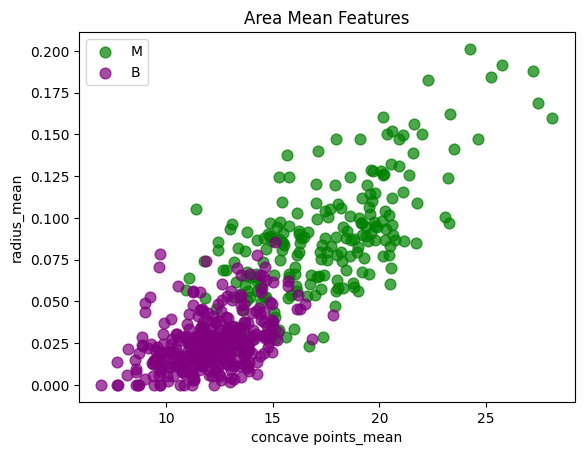

In [11]:
for diagnosis in df['diagnosis'].unique() :
    subset = df[df['diagnosis'] == diagnosis]
    if diagnosis == 'M':
        color = 'green'
        marker = 'o'
        label = 'M'
    else:
        color = 'purple'
        marker = '^'
        label = 'B'
        marker = 'o'
    plt.scatter( subset['radius_mean'],subset['concave points_mean'], c=color, marker=marker, label=label, alpha=0.7, s=60)
plt.title("Area Mean Features")
plt.legend()
plt.ylabel("radius_mean")
plt.xlabel("concave points_mean")

In [18]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['diagnosis'])

# Classification-Tree in sickit learn

In [ ]:
# ensure X and y are numpy arrays (avoid pyarrow-backed arrays which don't support advanced indexing)
X = df.drop('diagnosis', axis=1).to_numpy()
y_labels = df['diagnosis'].to_numpy()


X_train, X_test, y_train, y_test = train_test_split(X, y_labels, test_size=0.2, stratify=y_labels, random_state=1)

dt = DecisionTreeClassifier(max_depth=2, random_state=1)

In [26]:
# fit dt to the training set
dt.fit(X_train,y_train)

# Predict the test 
y_pred = dt.predict(X_test)

# Evaluate Score
accuracy_score(y_test,y_pred)


0.9035087719298246